In [1]:
# Import pandas for reading csv file
import pandas as pd

In [2]:
# Load file as a dataframe
df = pd.read_csv("../../data/loan_data.csv")

In [3]:
# Display first 5 entries of DataFrame
df.head(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
# Display columns with the percentages of missing data
df.isna().sum() / len(df) * 100

Loan_ID              0.000000
Gender               0.000000
Married              0.000000
Dependents           2.006689
Education            0.000000
Self_Employed        0.000000
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.511706
Loan_Amount_Term     2.341137
Credit_History       8.193980
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [6]:
# Display detailed information about Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            598 non-null    object 
 1   Gender             598 non-null    object 
 2   Married            598 non-null    object 
 3   Dependents         586 non-null    float64
 4   Education          598 non-null    object 
 5   Self_Employed      598 non-null    object 
 6   ApplicantIncome    598 non-null    int64  
 7   CoapplicantIncome  598 non-null    float64
 8   LoanAmount         577 non-null    float64
 9   Loan_Amount_Term   584 non-null    float64
 10  Credit_History     549 non-null    float64
 11  Property_Area      598 non-null    object 
 12  Loan_Status        598 non-null    object 
dtypes: float64(5), int64(1), object(7)
memory usage: 60.9+ KB


In [7]:
# Fill the missing values in the 'Credit_History' column with the mode
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode())

In [8]:
# Display new 'Credit_History' column
df["Credit_History"]

0      1.0
1      1.0
2      1.0
3      1.0
4      1.0
      ... 
593    1.0
594    1.0
595    1.0
596    1.0
597    0.0
Name: Credit_History, Length: 598, dtype: float64

In [9]:
# Drop all null values from DataFrame
df = df.dropna()

In [10]:
# Check if missing values remain
df.isna().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

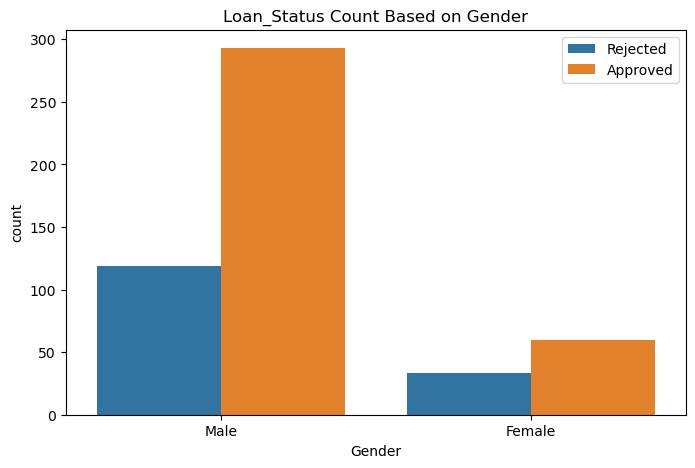

In [11]:
# Import seaborn and plot and save the 'Loan_Status' count of male and female category
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize = (8, 5))
sns.countplot(x = "Gender", hue = "Loan_Status", data = df)
plt.title("Loan_Status Count Based on Gender")
plt.legend(["Rejected", "Approved"])
plt.savefig("../../figures/eda/loan/loan_status_count_by_gender.png", dpi = 500, bbox_inches = "tight")
plt.show()

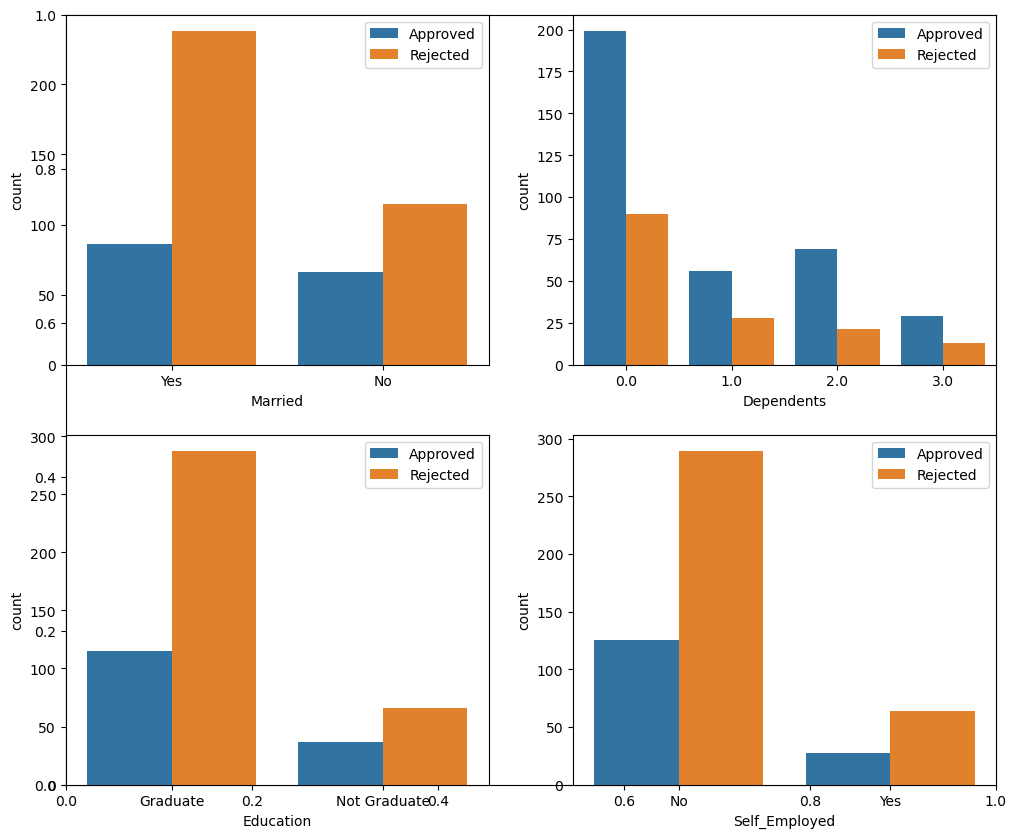

In [12]:
# Import matplotlib and display and save 'Loan_Status' count for the other features
import matplotlib.pyplot as plt
plt.subplots(figsize = (12, 10))
for i, col in enumerate(df.loc[:, "Married":"Self_Employed"].columns, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x = col, hue ='Loan_Status', data = df)
    plt.legend(["Approved", "Rejected"])
    plt.grid(False)
plt.savefig("../../figures/eda/loan/loan_status_count_by_categories.png", bbox_inches = "tight", dpi = 500)

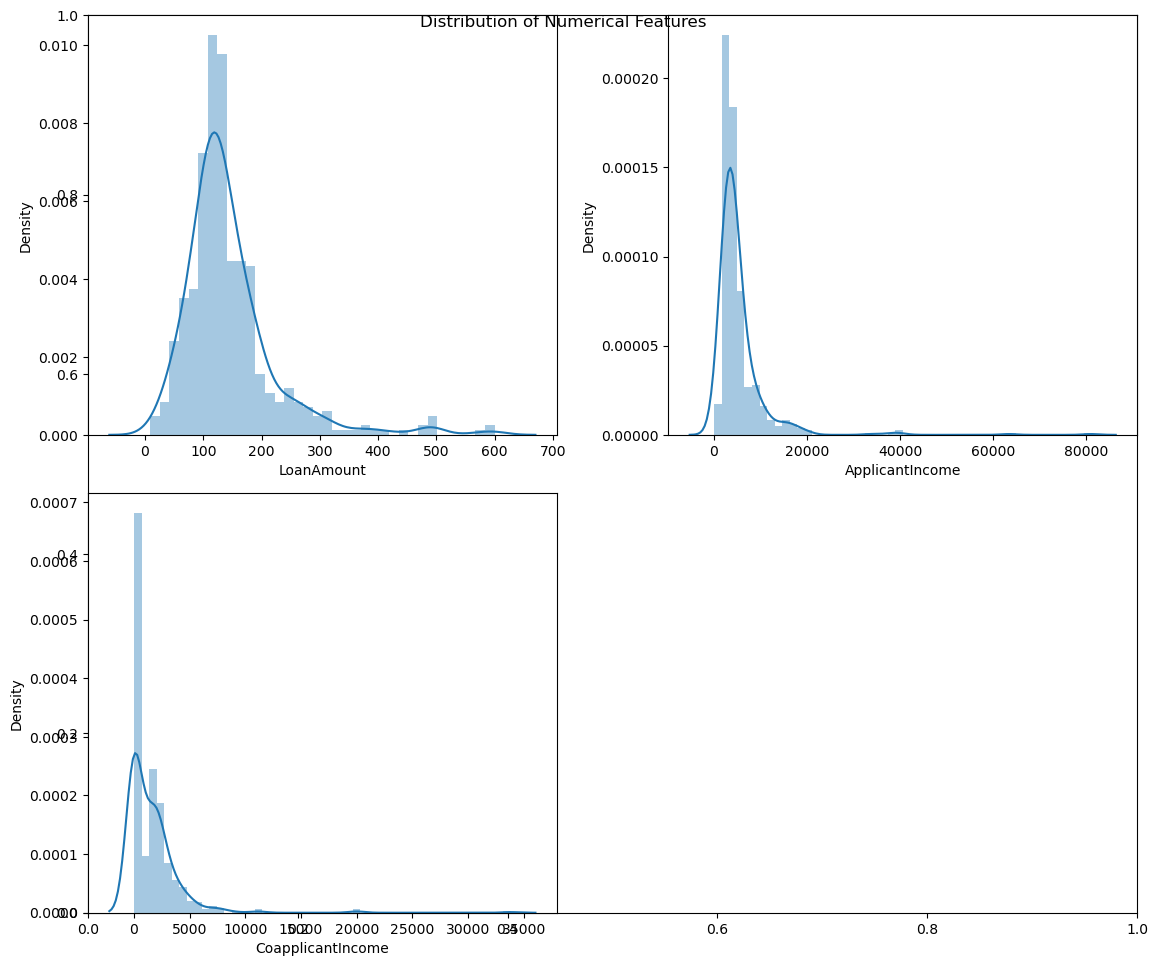

In [13]:
import warnings
warnings.filterwarnings("ignore")
# Displayand save Gaussian distrbution of 'LoanAmount' feature
plt.subplots(figsize = (12, 10))
for i, col in enumerate(["LoanAmount", "ApplicantIncome", "CoapplicantIncome"], 1):
    plt.subplot(2, 2, i)
    sns.distplot(df[col])
plt.tight_layout()
plt.suptitle("Distribution of Numerical Features")
plt.savefig("../../figures/eda/loan/distribution_of_numerical_features.png", dpi = 500, bbox_inches = 'tight')
plt.show()

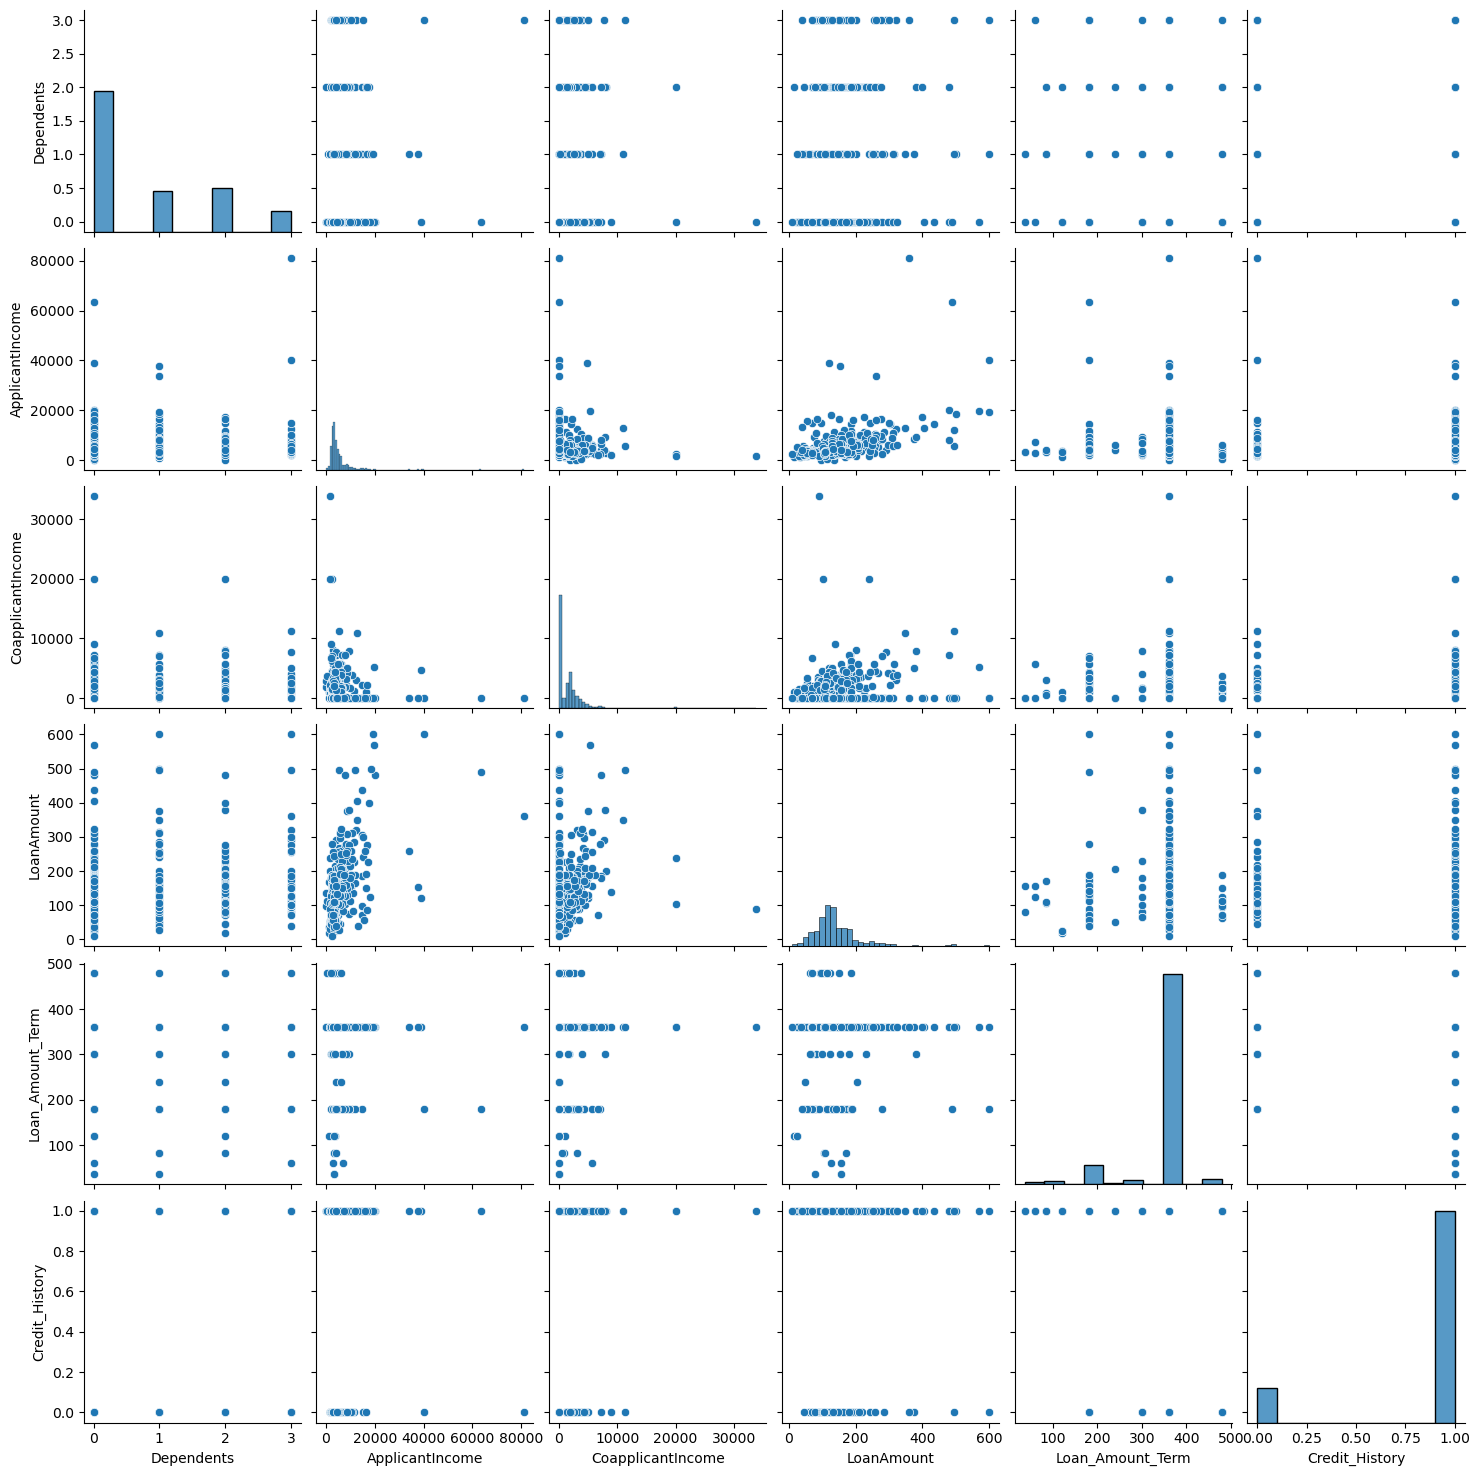

In [14]:
# Display and save correlation plot of all the features against one another
sns.pairplot(data = df)
plt.savefig("../../figures/eda/loan/correlation_plot_of_feeatures.png", dpi = 500, bbox_inches = "tight")
plt.show()

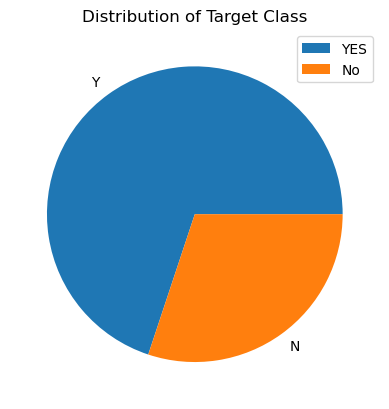

In [17]:
# Display and save piechart showing the target distribution
plt.pie(df["Loan_Status"].value_counts(), labels = df["Loan_Status"].value_counts().index)
plt.legend(["YES", "No"])
plt.title("Distribution of Target Class")
plt.savefig("../../figures/eda/loan/distribution_of_target_class.png")
plt.show()

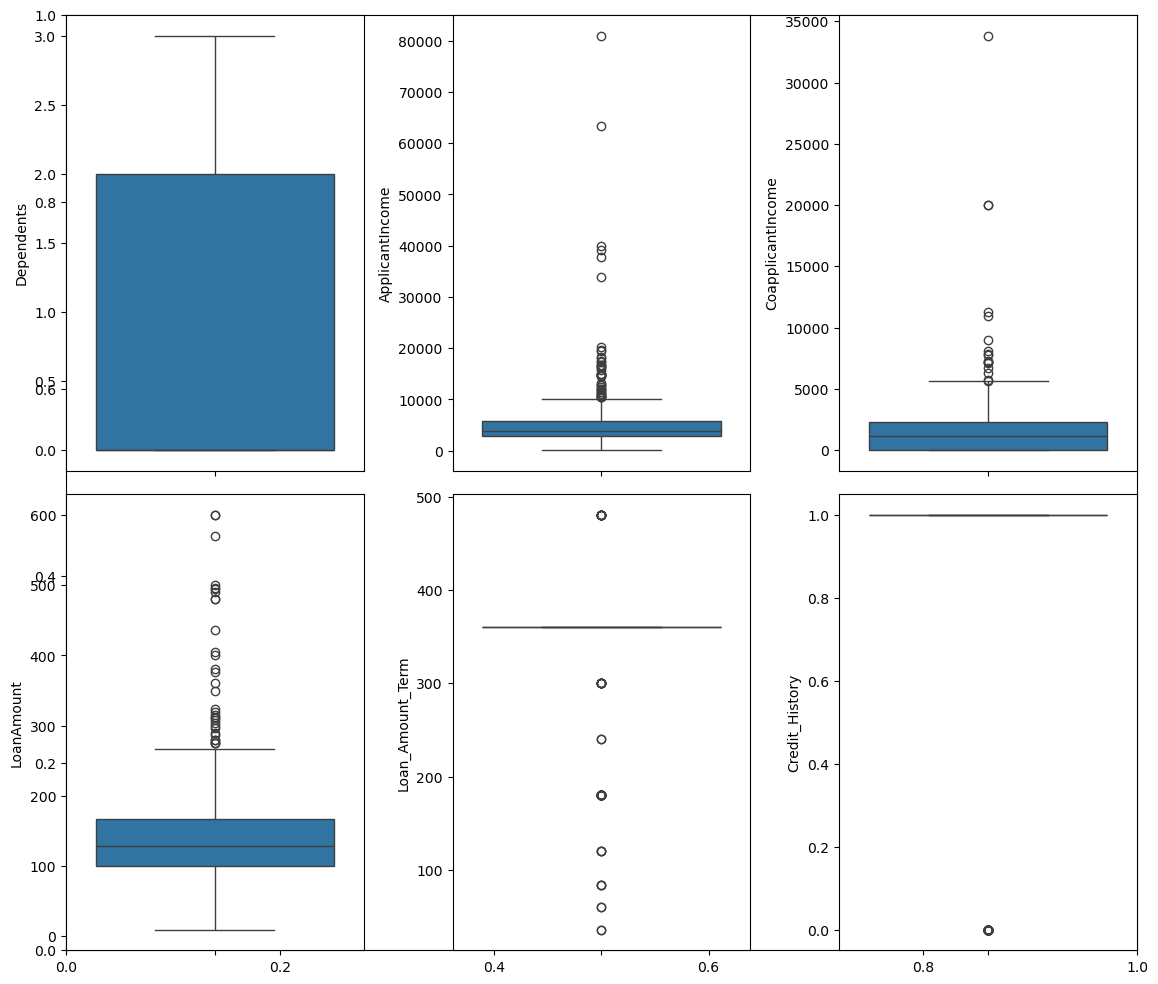

In [18]:
# Display and Save Boxplots for numerical features
plt.subplots(figsize = (12, 10))
for i, col in enumerate(df.select_dtypes(["int", "float"]).columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(df[col])

plt.tight_layout()

plt.savefig("../../figures/eda/loan/boxplots_showing_outliers_for_numerical_features.png", dpi = 500, bbox_inches = "tight")
plt.show()

In [19]:
# Correlation matrix for DataFrame
cm = df.corr(numeric_only = True)

(cm > .7) | (cm < -.7)

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
Dependents,True,False,False,False,False,False
ApplicantIncome,False,True,False,False,False,False
CoapplicantIncome,False,False,True,False,False,False
LoanAmount,False,False,False,True,False,False
Loan_Amount_Term,False,False,False,False,True,False
Credit_History,False,False,False,False,False,True


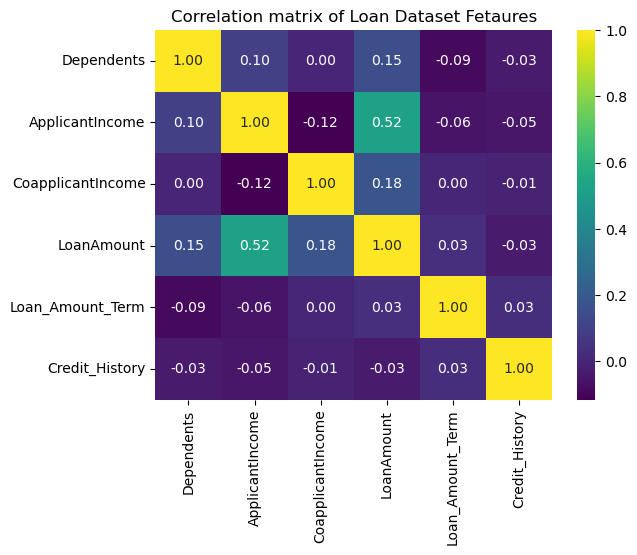

In [20]:
# Display and save Heatmap from Correlation Matrix
sns.heatmap(cm, annot = True, cmap = "viridis", fmt = ".2f")
plt.title("Correlation matrix of Loan Dataset Fetaures")
plt.savefig("../../figures/eda/loan/heatmap_of_correlation_matrix.png")
plt.show()

In [21]:
# Import OVersampler to balance target classes
from imblearn.over_sampling import RandomOverSampler

In [22]:
# Import preprocessing and training Libraries
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from scipy.stats import randint, uniform, loguniform

In [33]:
# Create dictionary of model names, instances and parameters
models = [
    ("LogisticRegression", LogisticRegression(), {
    'solver': ['lbfgs', 'liblinear'],
    'C': [0.1, 1, 10],
    'max_iter': [1000]
}), ("SVC", SVC(),{
    'C': [0.01,  0.1, 10, 100], # Search across orders of magnitude
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'gamma': ['scale', 'auto'],
    'degree': [2, 4] # Only used by 'poly' kernel
}), ("XGB", XGBClassifier(), {
    'n_estimators': [100, 400],
    'learning_rate': [0.1, 10],
    'max_depth': [6, 10],
    'subsample': [0.5, 1], # 0.5 to 1.0
    'colsample_bytree': [0.5, 1],
    'gamma': [0.1, 10]
}), ('RandomForest', RandomForestClassifier(), {
    'n_estimators': [100, 400],
    'max_depth': [None, 10, 40],
    'min_samples_split': [4, 10],
    'min_samples_leaf': [1],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy']
}), ("KNeighbors", KNeighborsClassifier(), {
    'n_neighbors': [4, 10, 20],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'leaf_size': [20, 50],
    'p': [1, 2] # 1 is manhattan, 2 is euclidean
})
]

In [24]:
# split dataset into training and testing
df_train, df_test = train_test_split(df, test_size =.2, random_state = 42)

In [25]:
# Initialize OverSampler to balance target classes
ros = RandomOverSampler(sampling_strategy = "minority", random_state = 42)
X, y = ros.fit_resample(df_train.drop(columns = "Loan_Status"), df_train["Loan_Status"])
# Recombine features and target
df_train = pd.concat([X, y], axis = 1)

In [26]:
# Create array of number type feature names
num_cols = df.select_dtypes(["int", "float"]).columns

# Create array of object type feature names
cat_cols = df.drop(columns = ["Loan_Status", "Loan_ID"]).select_dtypes("object").columns

# Crete pipeline for processing each category
num_pipeline = Pipeline([("scaler", StandardScaler())])
cat_pipeline = Pipeline([("onehot", OneHotEncoder()), ("scaler", StandardScaler(with_mean = False)),
                        ])
# Initialise preprocessor
preprocessor = ColumnTransformer([("num", num_pipeline, num_cols),
                                 ("cat", cat_pipeline, cat_cols)])
# Create training and testing feature sets
X_train = df_train.drop(columns = ["Loan_ID", 'Loan_Status'])
X_test = df_test.drop(columns = ["Loan_ID", 'Loan_Status'])

# Create training and testing Target sets
y_train = df_train["Loan_Status"].map({'Y': 1, 'N': 0}).to_numpy()
y_test = df_test["Loan_Status"].map({'Y': 1, 'N': 0}).to_numpy()

# Transform Training and Testing Feature sets
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [34]:
# Dictionary for storing tuned models and parameters
tuned_models = {}
# Tune Hyperparameters usin GridSearchCV
for model_name, model, params in models:
    search = GridSearchCV(model, param_grid = params, cv = 5,
                                scoring = 'accuracy')
    search.fit(X_train, y_train)
    tuned_models[model_name] = [search.best_estimator_, search.best_params_, search.best_score_]
    print(model_name, tuned_models[model_name][2])

LogisticRegression 0.6859295659295659
SVC 0.8014414414414415
XGB 0.871891891891892
RandomForest 0.8808681408681409
KNeighbors 0.8683374283374283


In [43]:
# Dictionary store of parameters of best estimator
params = tuned_models['RandomForest'][1]

# Initialize best performing model and fit on Training set
model = RandomForestClassifier(**params)
model.fit(X_train, y_train)

,n_estimators,400
,criterion,'entropy'
,max_depth,None
,min_samples_split,4
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [39]:
# Import confusion matrix and classification report to display model performance
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [44]:
# Run prediction on testing set
preds = model.predict(X_test)
# Print report of model performance 
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.70      0.64      0.67        25
           1       0.88      0.91      0.90        76

    accuracy                           0.84       101
   macro avg       0.79      0.77      0.78       101
weighted avg       0.84      0.84      0.84       101



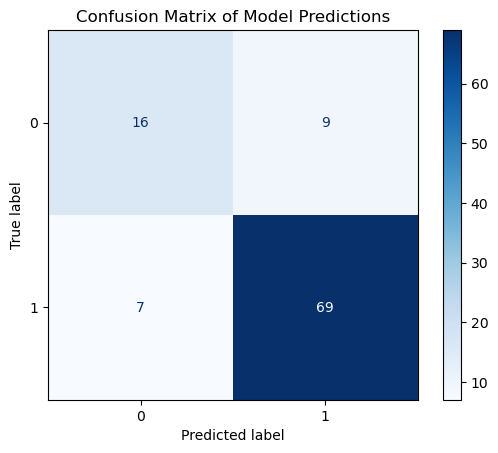

In [62]:
# Display and save confusio matrix for Predicted and Actual Values
cm = confusion_matrix(y_test, best_model.predict(X_test))
ConfusionMatrixDisplay(cm).plot(cmap = "Blues")
plt.title("Confusion Matrix of Model Predictions")
plt.savefig("../../figures/results/loan/confusion_matrix_for_model_predictions.png")
plt.show()

In [61]:
# From the Results we can conclude that our model performed fairly well
# With an accuracy of 84%